In [1]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data
from skimage.transform import resize
from numpy.fft import fft2, ifft2, ifftshift

image = data.camera()
image = resize(image, (256, 256))
M, N = image.shape

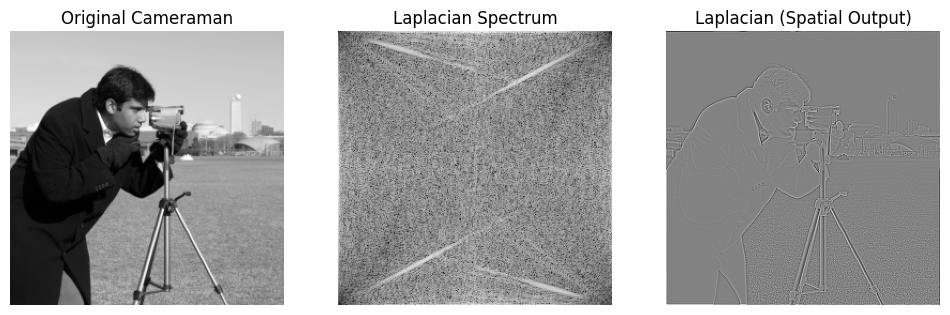

In [2]:
u = np.fft.fftfreq(M).reshape(-1, 1)
v = np.fft.fftfreq(N).reshape(1, -1)
laplacian_filter = -4 * (np.pi ** 2) * (u**2 + v**2)

F = fft2(image)
F_lap = F * laplacian_filter
laplacian_image = ifft2(F_lap).real

plt.figure(figsize=(12, 5))
plt.subplot(1, 3, 1)
plt.imshow(image, cmap='gray')
plt.title('Original Cameraman')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(np.log(1 + np.abs(F_lap)), cmap='gray')
plt.title('Laplacian Spectrum')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(laplacian_image, cmap='gray')
plt.title('Laplacian (Spatial Output)')
plt.axis('off')
plt.show()

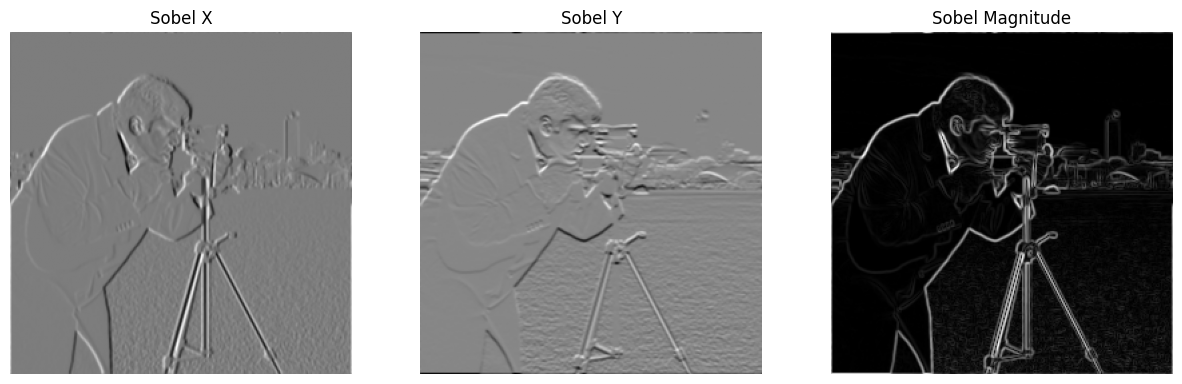

In [3]:
def center_embed_kernel(kernel, shape):
    padded = np.zeros(shape)
    kh, kw = kernel.shape
    ph, pw = shape
    cy, cx = ph // 2, pw // 2
    padded[cy - kh//2:cy - kh//2 + kh, cx - kw//2:cx - kw//2 + kw] = kernel
    return fft2(ifftshift(padded))

sobel_x = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]])
sobel_y = np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]])

H_x = center_embed_kernel(sobel_x, (M, N))
H_y = center_embed_kernel(sobel_y, (M, N))

G_x = ifft2(F * H_x).real
G_y = ifft2(F * H_y).real
sobel_magnitude = np.sqrt(G_x**2 + G_y**2)

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(G_x, cmap='gray')
plt.title('Sobel X')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(G_y, cmap='gray')
plt.title('Sobel Y')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(sobel_magnitude, cmap='gray')
plt.title('Sobel Magnitude')
plt.axis('off')
plt.show()